In [51]:
# Import des paquets

import pandas as pd
import os
import load_data.donnees_chargement
from great_tables import GT


In [ ]:
# Import des donnees

parite = load_data.donnees_chargement.load_parite()
parite.head()

In [ ]:
# Calcul du temps de parole féminin et masculin par chaine

parite_chaine = parite.groupby('channel_code').agg(
    channel_name = ('channel_name', 'first'),
    female_duration = ('female_duration', 'sum'),
    male_duration = ('male_duration', 'sum')
).reset_index()

parite_chaine['proportion_female'] = parite_chaine['female_duration'] / (parite_chaine['female_duration'] + parite_chaine['male_duration'])

parite_chaine = parite_chaine.sort_values(by='proportion_female', ascending=False).reset_index()

In [75]:
# Affichage de la part de parole féminine par chaîne

(
    GT(parite_chaine[['channel_name', 'proportion_female']])
    .tab_header(
        title="Part du temps de parole féminin par chaîne",
        subtitle="De janvier 2010 à février 2019"
    )
    .fmt_percent(columns="proportion_female", decimals=0)
    .cols_label(
        channel_name = "Chaîne",
        proportion_female = "Part du temps de parole féminin"
    )
    .cols_width(cases={
        'channel_name': '70px',
        'proportion_female': '150px'
    })
    .tab_source_note("Source : INA")
)

GT(_tbl_data=  channel_name  proportion_female
0           M6           0.411471
1          TF1           0.364962
2     France 2           0.343634
3     France 3           0.318630
4         ARTE           0.291878, _body=<great_tables._gt_data.Body object at 0x7f719cfcc460>, _boxhead=Boxhead([ColInfo(var='channel_name', type=<ColInfoTypeEnum.default: 1>, column_label='Chaîne', column_align='left', column_width='70px'), ColInfo(var='proportion_female', type=<ColInfoTypeEnum.default: 1>, column_label='Part du temps de parole féminin', column_align='right', column_width='150px')]), _stub=<great_tables._gt_data.Stub object at 0x7f7197955470>, _spanners=Spanners([]), _heading=Heading(title='Part du temps de parole féminin par chaîne', subtitle='De janvier 2010 à février 2019', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x7f719d956a50>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x7f719d9557f0>, _source_notes=['Source : INA'], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x7f71979557f0>, _formats=[<great_tables._gt_data.FormatInfo object at 0x7f7197955a90>], _substitutions=[], _col_merge=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_right_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_right_color=OptionsInfo(scss=True, category='table', type='value', value='#D3D3D3'), table_border_bottom_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_bottom_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_bottom_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_bottom_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_left_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_left_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_left_color=OptionsInfo(scss=True, category='table', type='value', value='#D3D3D3'), heading_background_color=OptionsInfo(scss=True, category='heading', type='va

In [41]:
# Calcul du temps de parole masculin et fémnin par chaine et jour de la semaine


parite_jour_chaine = parite.groupby(['channel_code', 'week_day_number']).agg(
    week_day = ('week_day', 'first'),
    channel_name = ('channel_name', 'first'),
    female_duration = ('female_duration', 'sum'),
    male_duration = ('male_duration', 'sum')
).reset_index()

parite_jour_chaine['proportion_female'] = parite_jour_chaine['female_duration'] / (parite_jour_chaine['female_duration'] + parite_jour_chaine['male_duration'])

In [70]:
# Representation de la proportion de temps de parole féminin par jour de la semaine

def diagramme_temps_parole_jour(code_chaine):
    parite_jour = parite_jour_chaine[
        parite_jour_chaine['channel_code'] == code_chaine
    ].reset_index()
    diag = parite_jour.sort_values(by='week_day_number').plot.bar(
        x = 'week_day',
        y = 'proportion_female',
        title = "Temps de parole féminin par jour pour la chaîne " + parite_jour['channel_name'][0],
        legend=False,
        xlabel="Jour",
        ylabel="Part de temps de parole féminin",
        grid=True
    )
    
    diag.xaxis.grid(False)

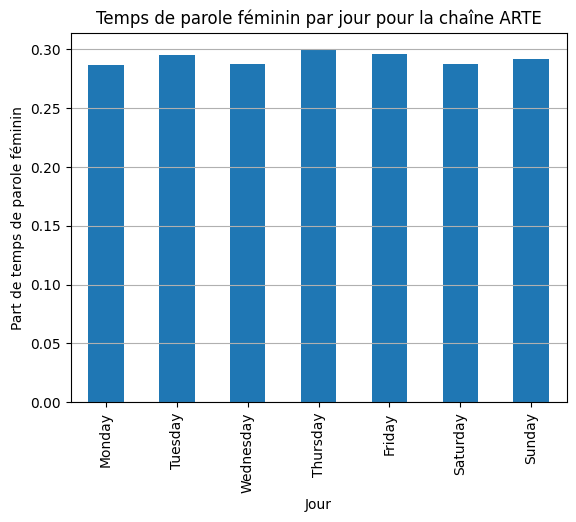

In [43]:
# Pour Arte : pas de différence entre les jours

diagramme_temps_parole_jour('ART')

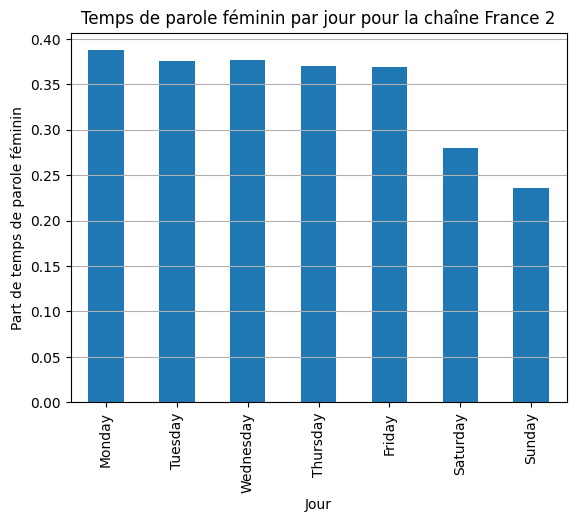

In [44]:
# Pour France 2 : décrochage de la part de parole féminine le week-end

diagramme_temps_parole_jour('FR2')